Предсказание стоимости медицинских страховок  
  
Датасет: Medical Cost Personal Dataset.  


### Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

pd.set_option('display.precision', 2)

random_state = 13

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55
1334,18,female,31.92,0,no,northeast,2205.98
1335,18,female,36.85,0,no,southeast,1629.83
1336,21,female,25.80,0,no,southwest,2007.94


### Анализ данных

In [4]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [5]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [6]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

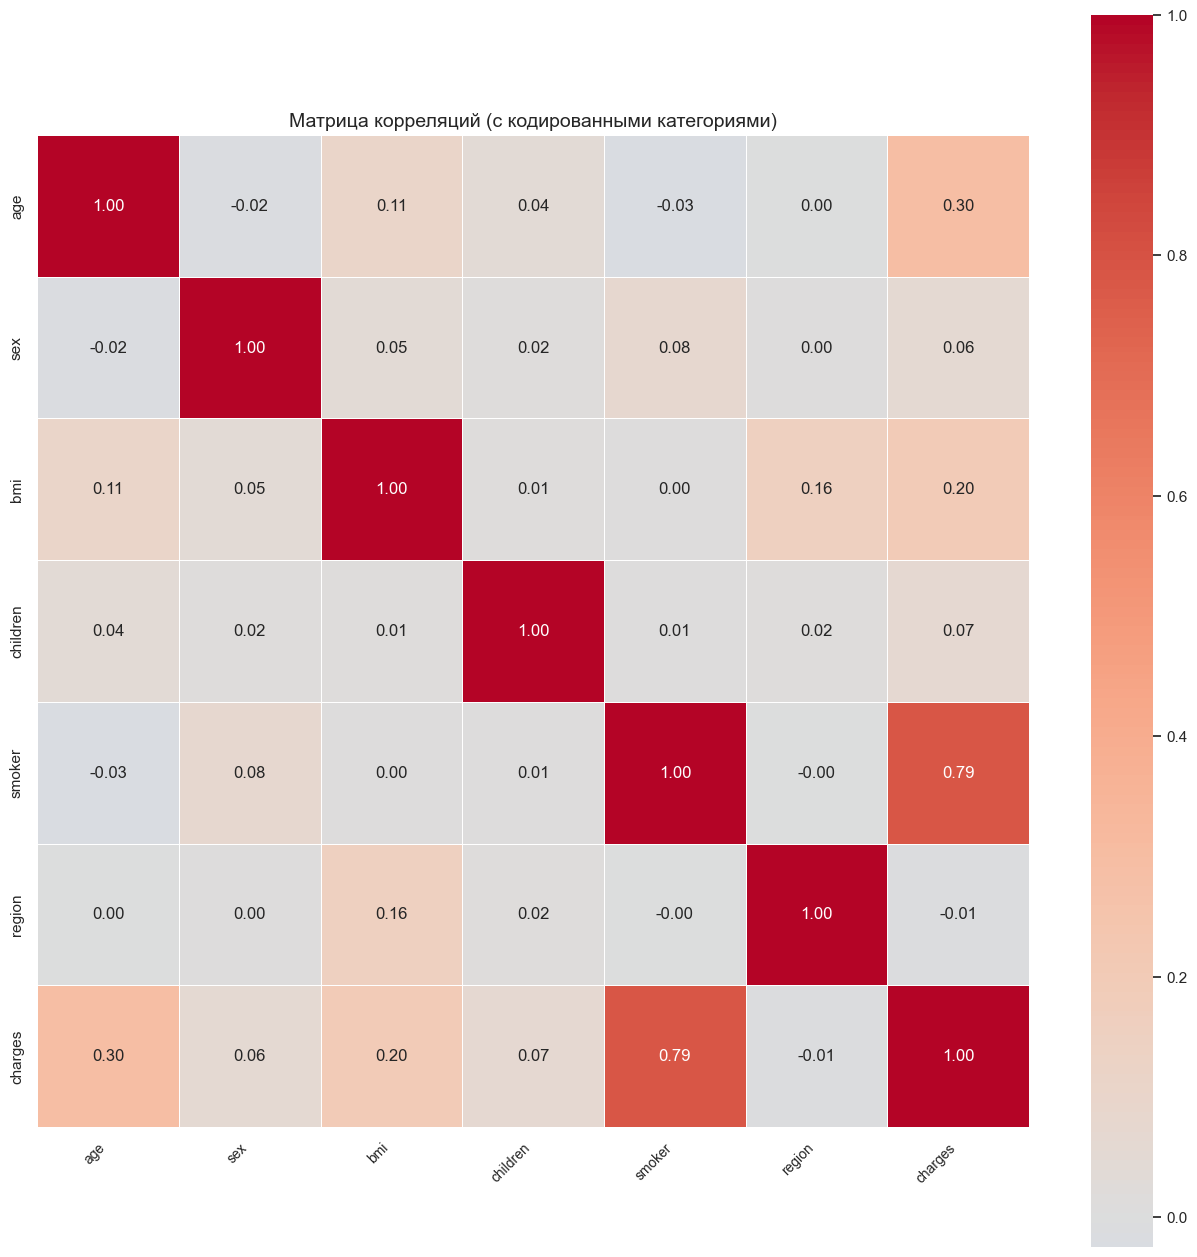

In [8]:
corr_matrix = df.corr()

plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Матрица корреляций (с кодированными категориями)', fontsize=14)
plt.show()

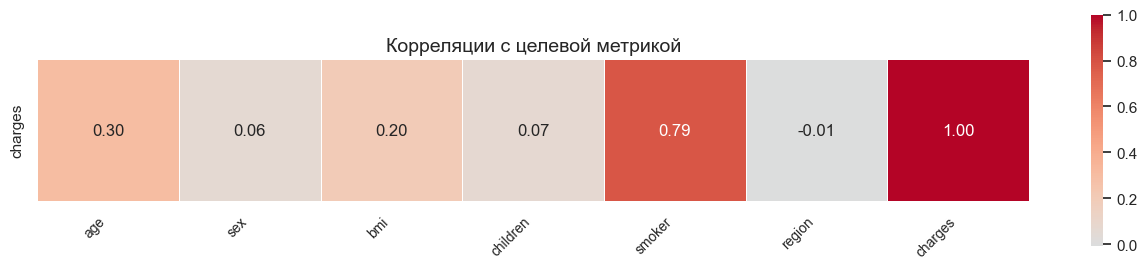

In [9]:
plt.figure(figsize=(16, 3))
sns.heatmap(corr_matrix[['charges']].T, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Корреляции с целевой метрикой', fontsize=14)
plt.show()

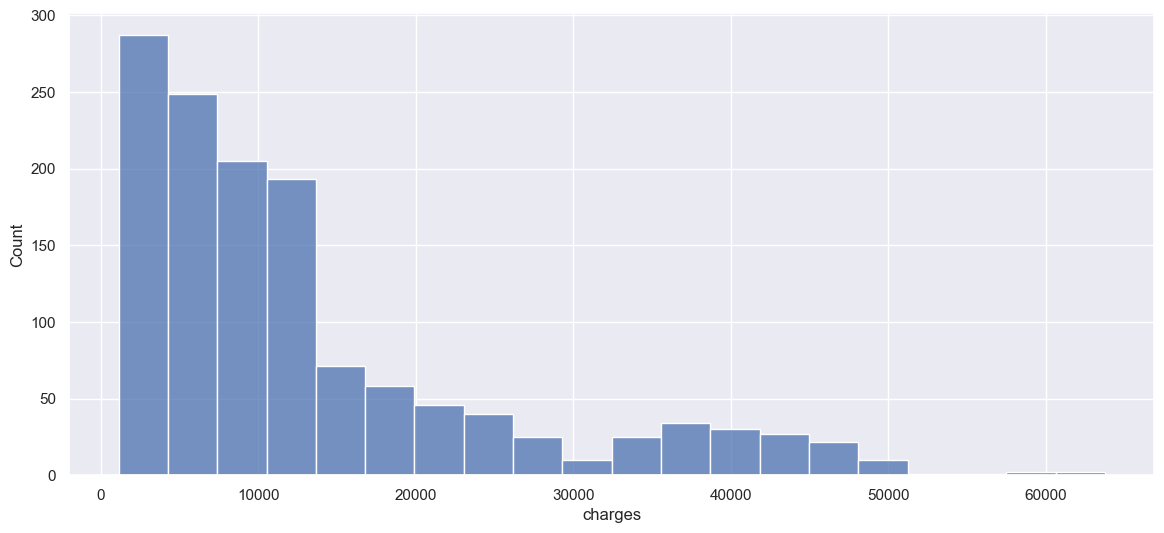

In [10]:
plt.figure(figsize=(14, 6))
sns.histplot(data=df, x='charges', bins=20)
plt.show()

In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [12]:
categorial_features = ['sex', 'children', 'smoker', 'region']
numeric_features = ['age', 'bmi']

#### Точечные графики для числовых признаков

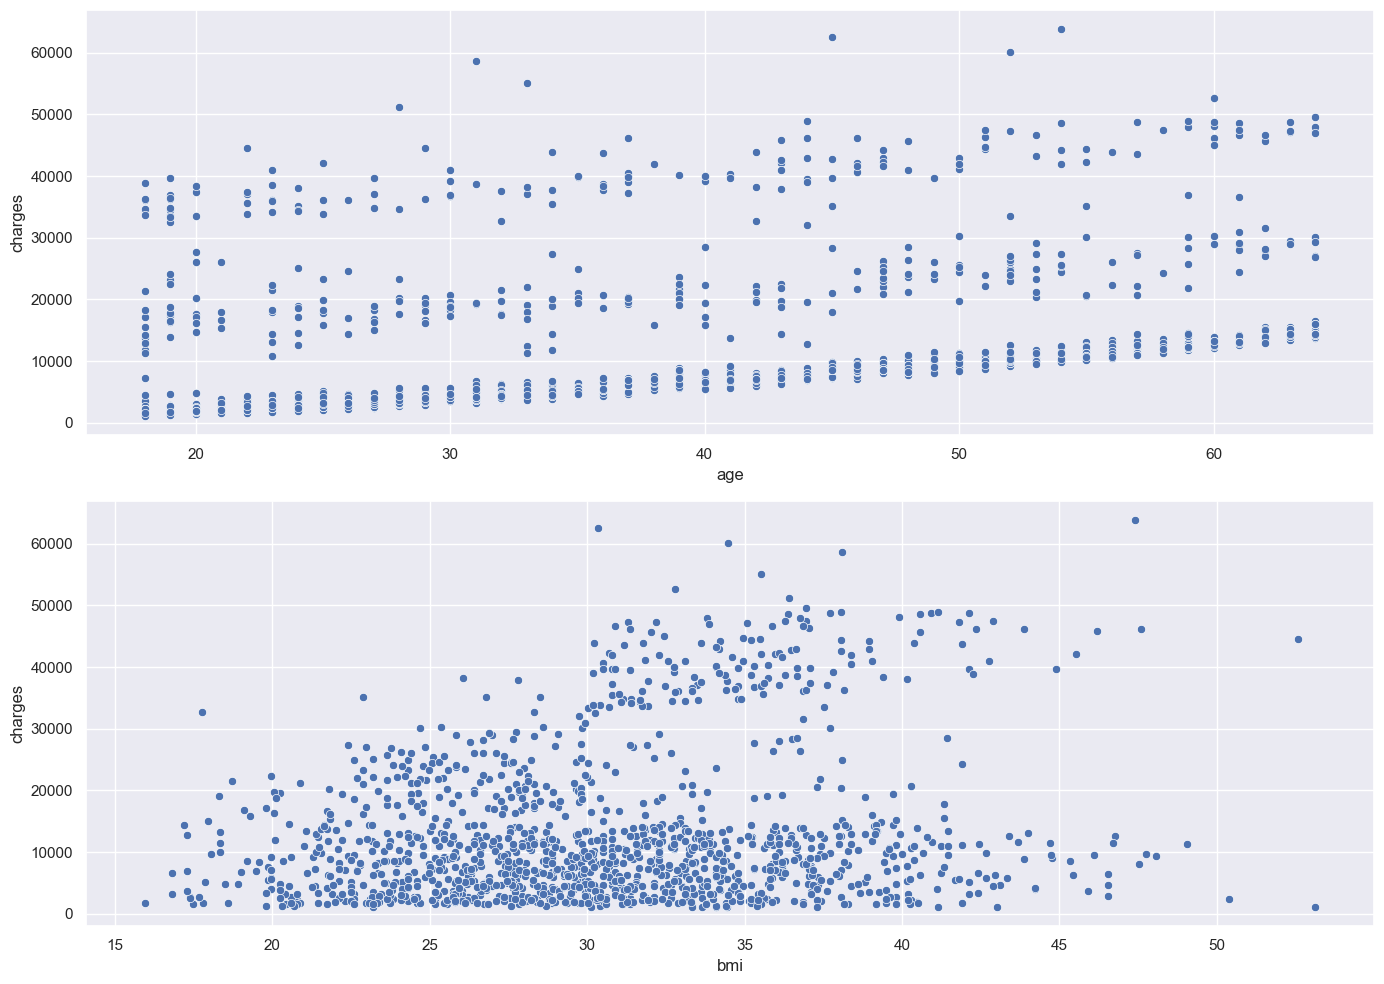

In [13]:
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(14, len(numeric_features) * 5))
for i in range(len(numeric_features)): 
    sns.scatterplot(data=df, x=numeric_features[i], y='charges', ax=axes[i])

plt.tight_layout()
plt.show()

##### Графики с цветом по признаку 'sex'

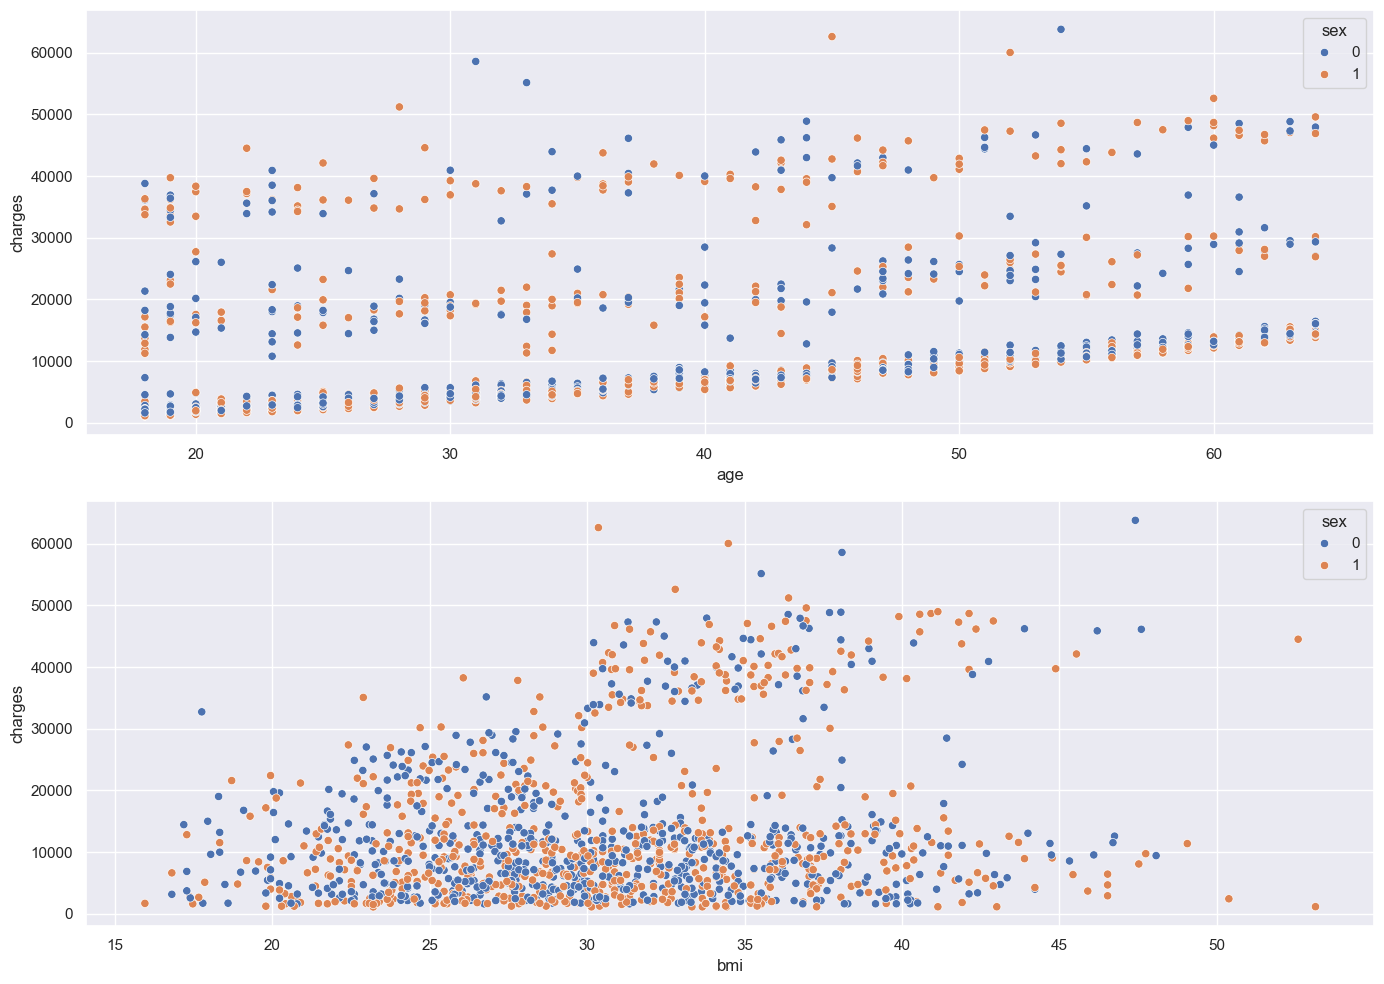

In [14]:
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(14, len(numeric_features) * 5))
for i in range(len(numeric_features)): 
    sns.scatterplot(data=df, x=numeric_features[i], y='charges', ax=axes[i], hue='sex')

plt.tight_layout()
plt.show()

##### Графики с цветом по признаку 'smoker'

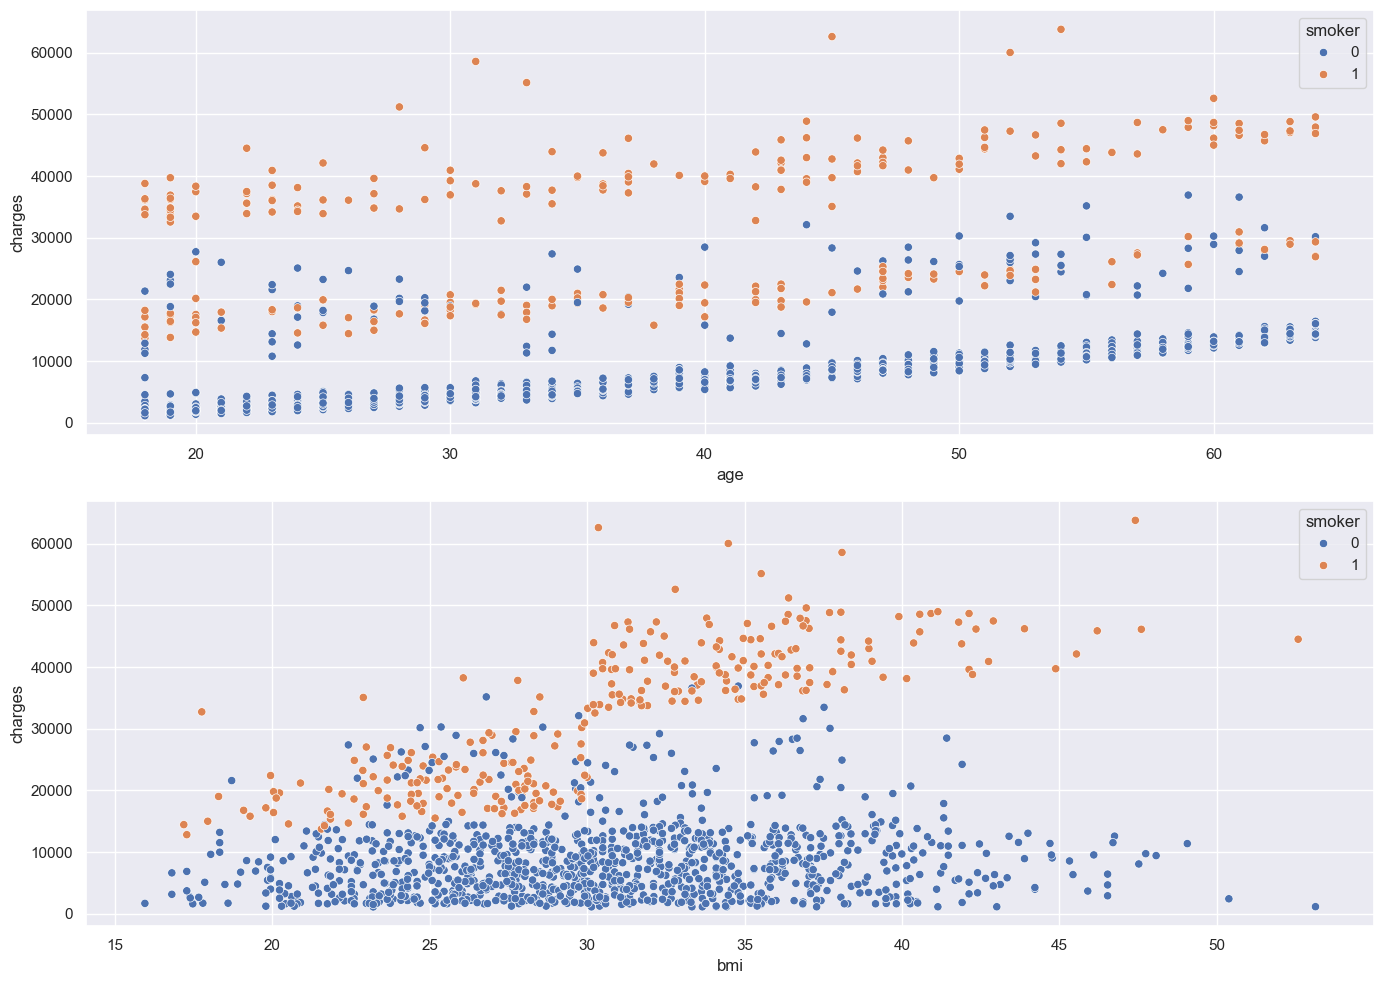

In [15]:
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(14, len(numeric_features) * 5))
for i in range(len(numeric_features)): 
    sns.scatterplot(data=df, x=numeric_features[i], y='charges', ax=axes[i], hue='smoker')

plt.tight_layout()
plt.show()

По графику видно, что на зависимость стоимости от числовых признаков сильно влияет курит человек или нет

##### Графики с цветом по признаку 'children'

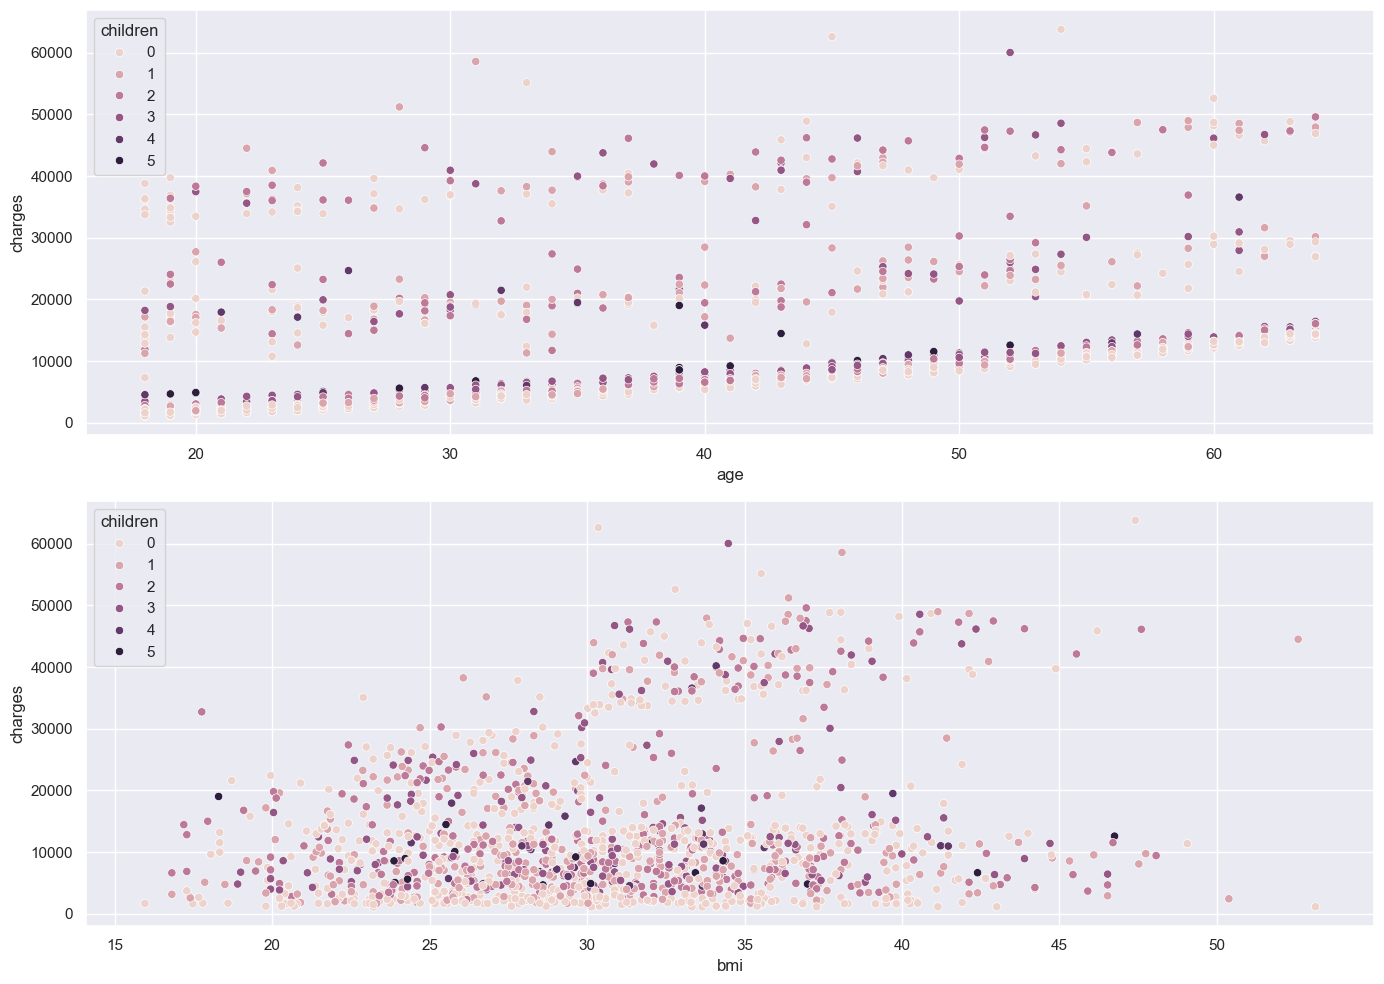

In [16]:
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(14, len(numeric_features) * 5))
for i in range(len(numeric_features)): 
    sns.scatterplot(data=df, x=numeric_features[i], y='charges', ax=axes[i], hue='children')

plt.tight_layout()
plt.show()

##### Графики с цветом по признаку 'region'

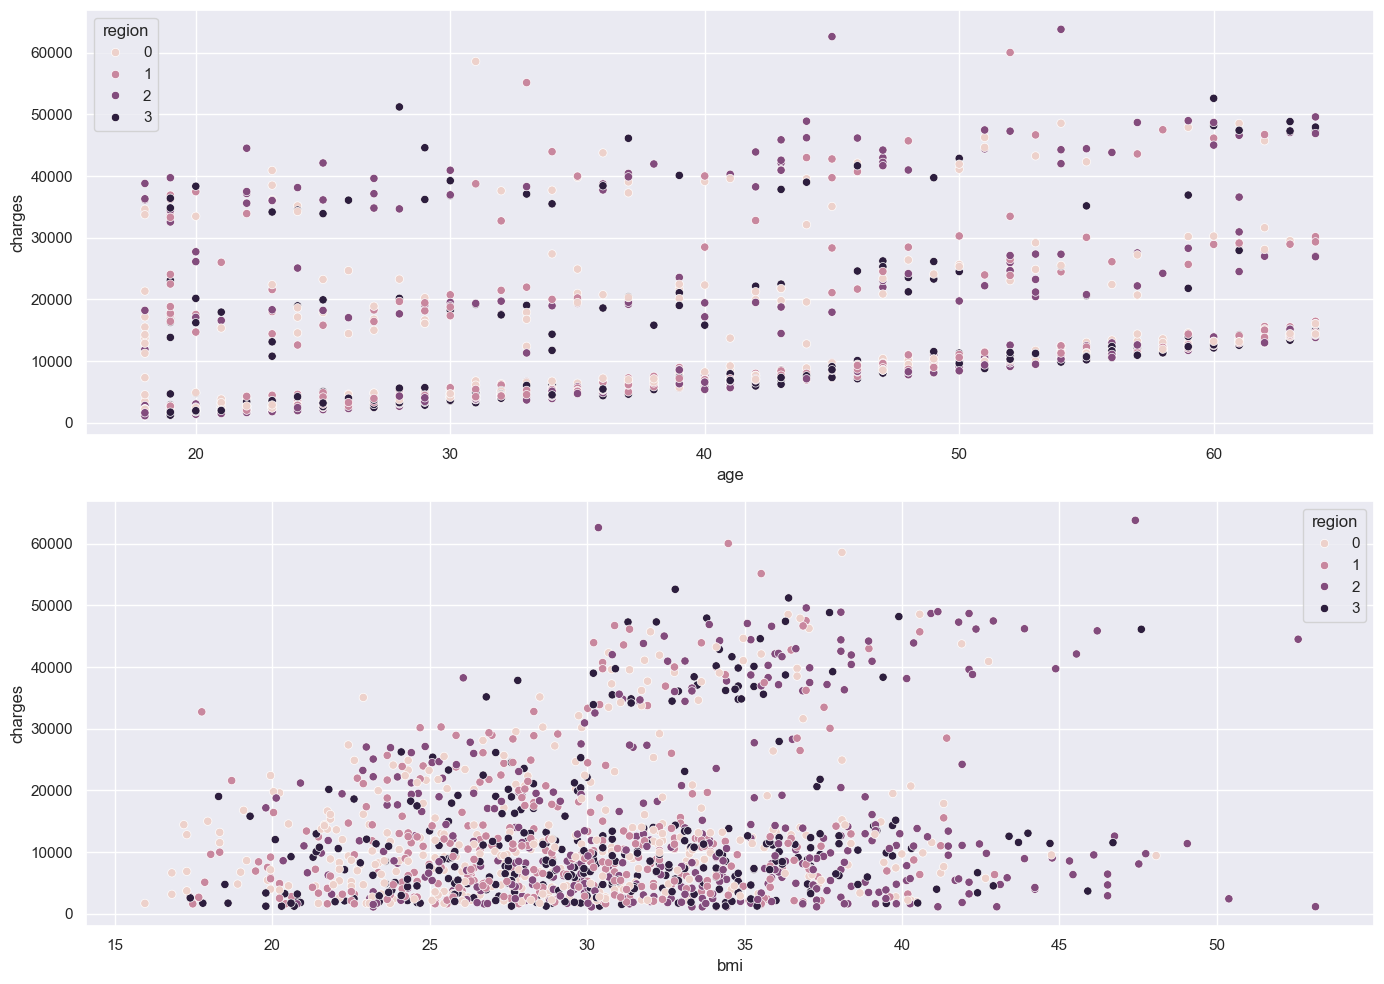

In [17]:
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(14, len(numeric_features) * 5))
for i in range(len(numeric_features)): 
    sns.scatterplot(data=df, x=numeric_features[i], y='charges', ax=axes[i], hue='region')

plt.tight_layout()
plt.show()

#### Диаграмма размаха для категориальных признаков

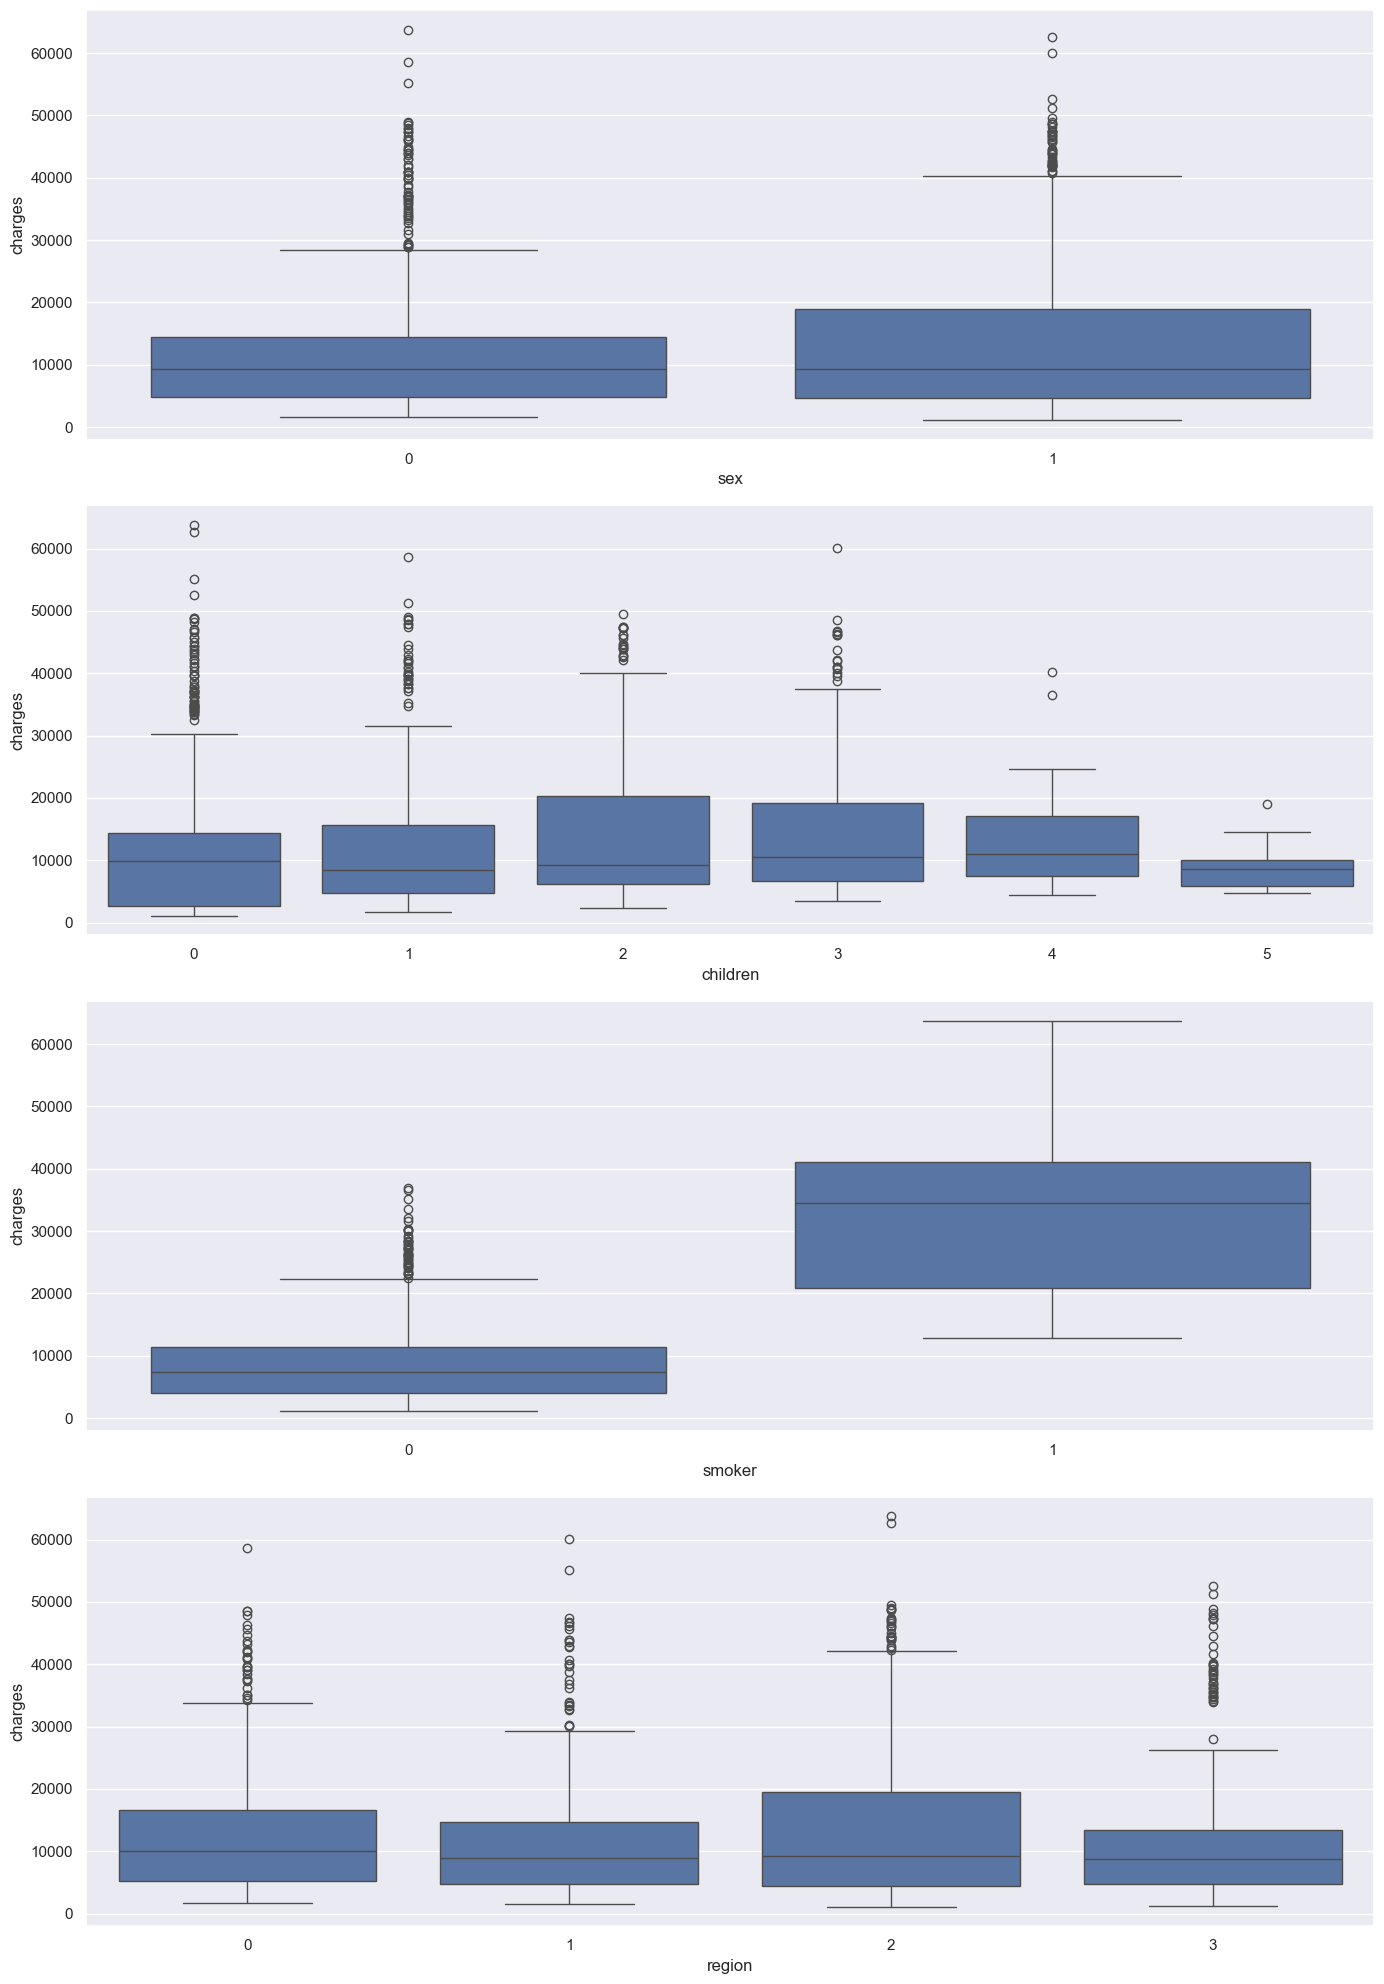

In [18]:
fig, axes = plt.subplots(len(categorial_features), 1, figsize=(14, len(categorial_features) * 5))
for i in range(len(categorial_features)): 
    sns.boxplot(data=df, x=categorial_features[i], y='charges', ax=axes[i])

plt.tight_layout()
plt.show()

### Разделение на Обучающую, валидационную и тестовую выборки

In [19]:
import os
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('insurance.csv')
X = df[categorial_features + numeric_features]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

os.makedirs('Train', exist_ok=True)
X_train.to_csv('Train/X.csv', index=False)
y_train.to_csv('Train/y.csv', index=False)

os.makedirs('Test', exist_ok=True)
X_test.to_csv('Test/X.csv', index=False)
y_test.to_csv('Test/y.csv', index=False)

### Анализ LinearRegression

In [20]:
X_train = pd.read_csv('Train/X.csv')
y_train = pd.read_csv('Train/y.csv').squeeze()

X_test = pd.read_csv('Test/X.csv')
y_test = pd.read_csv('Test/y.csv').squeeze()

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_test_pred = lr.predict(X_test)
y_train_pred = lr.predict(X_train)

lr_mae = mean_absolute_error(y_test, y_test_pred)
lr_mse = mean_squared_error(y_test, y_test_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_test_pred)

print(f'MAE (средняя абсолютная ошибка): {lr_mae:_.2f}')
print(f'MSE (средняя квадратичная ошибка): {lr_mse:_.2f}')
print(f'RMSE (корень из MSE): {lr_rmse:_.2f}')
print(f'R2 (коэффициент детерминации): {lr_r2:.4f}')

MAE (средняя абсолютная ошибка): 4_186.51
MSE (средняя квадратичная ошибка): 33_635_210.43
RMSE (корень из MSE): 5_799.59
R2 (коэффициент детерминации): 0.7833


In [24]:
feature_names = X.columns.tolist()
coefficients = lr.coef_
intercept = lr.intercept_

In [25]:
print(f'свободный член: {intercept:_.2f}')
print('Коэффициенты модели:')
for feature, coef in zip(feature_names, coefficients):
    print(f'  {feature}: {coef:_.2f}')

свободный член: -11_946.61
Коэффициенты модели:
  sex: -18.79
  children: 425.09
  smoker: 23_647.82
  region: -271.28
  age: 257.06
  bmi: 335.78


In [26]:
df_result = pd.DataFrame(
    {
        'Реальные': y_test,
        'Предсказанные lr': y_test_pred,
    }
)

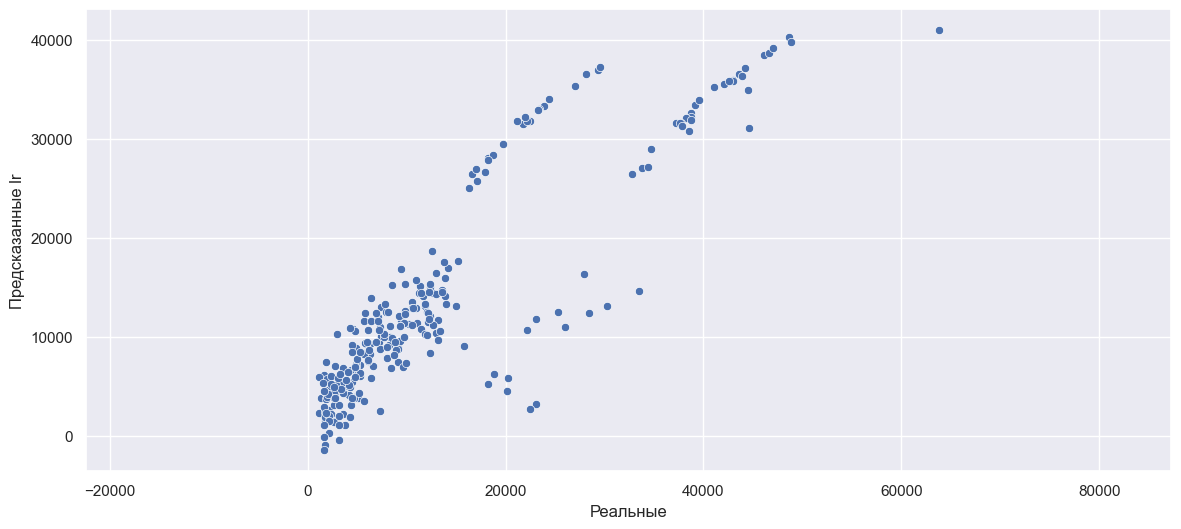

In [27]:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_result, x='Реальные', y='Предсказанные lr')
plt.axis('equal')
plt.show()

### Анализ CatBoostRegressor

In [28]:
X_train = pd.read_csv('Train/X.csv')
y_train = pd.read_csv('Train/y.csv').squeeze()

X_test = pd.read_csv('Test/X.csv')
y_test = pd.read_csv('Test/y.csv').squeeze()

In [29]:
from catboost import CatBoostRegressor
categorial_features = ['sex', 'smoker', 'region']
cat = CatBoostRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=13,
    verbose=100,
    cat_features=categorial_features
)

cat.fit(X_train, y_train, eval_set=(X_test, y_test), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.209657
0:	learn: 10145.4689705	test: 10586.1379737	best: 10586.1379737 (0)	total: 170ms	remaining: 16.8s
99:	learn: 3810.0617868	test: 4461.7947185	best: 4386.7503190 (25)	total: 3.35s	remaining: 0us

bestTest = 4386.750319
bestIteration = 25

Shrink model to first 26 iterations.


CatBoostRegressor(cat_features=['sex', 'smoker', 'region'], loss_function='RMSE', max_depth=5, n_estimators=100, random_state=13, verbose=100)

In [30]:
y_test_pred = cat.predict(X_test)
y_train_pred = cat.predict(X_train)

cat_mae = mean_absolute_error(y_test, y_test_pred)
cat_mse = mean_squared_error(y_test, y_test_pred)
cat_rmse = np.sqrt(cat_mse)
cat_r2 = r2_score(y_test, y_test_pred)

print(f'MAE (средняя абсолютная ошибка): {cat_mae:_.2f}')
print(f'MSE (средняя квадратичная ошибка): {cat_mse:_.2f}')
print(f'RMSE (корень из MSE): {cat_rmse:_.2f}')
print(f'R2 (коэффициент детерминации): {cat_r2:.4f}')

MAE (средняя абсолютная ошибка): 2_461.82
MSE (средняя квадратичная ошибка): 19_243_578.40
RMSE (корень из MSE): 4_386.75
R2 (коэффициент детерминации): 0.8760


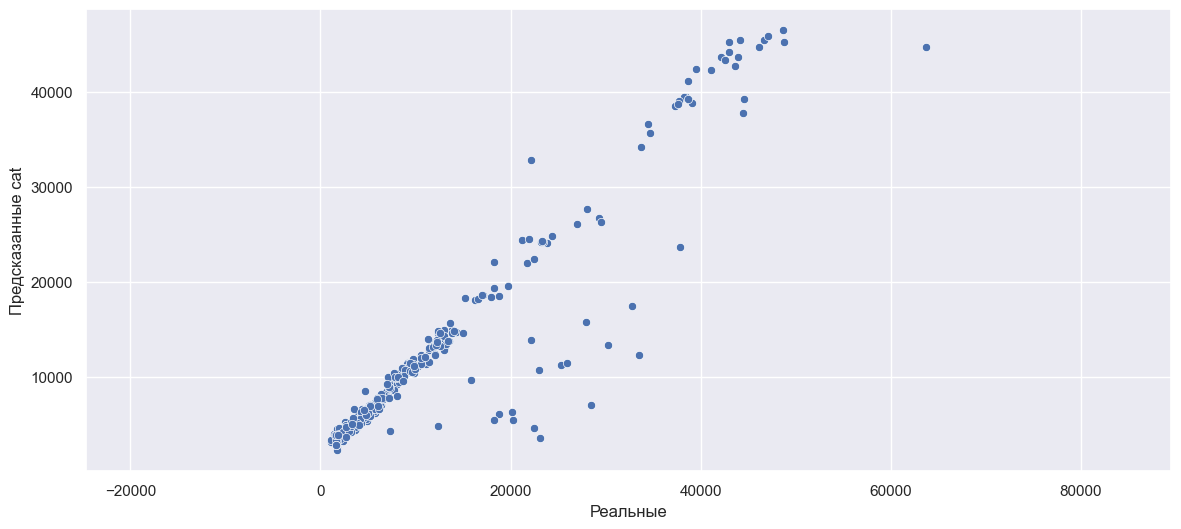

In [31]:
df_result['Предсказанные cat'] = cat.predict(X_test)

plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_result, x='Реальные', y='Предсказанные cat')
# min_val = min(real_sorted.min(), pred_sorted.min())
# max_val = max(real_sorted.max(), pred_sorted.max())
# plt.plot([0, max_val], [min_val, max_val], 'r--', label='y = x')
plt.axis('equal')
plt.show()

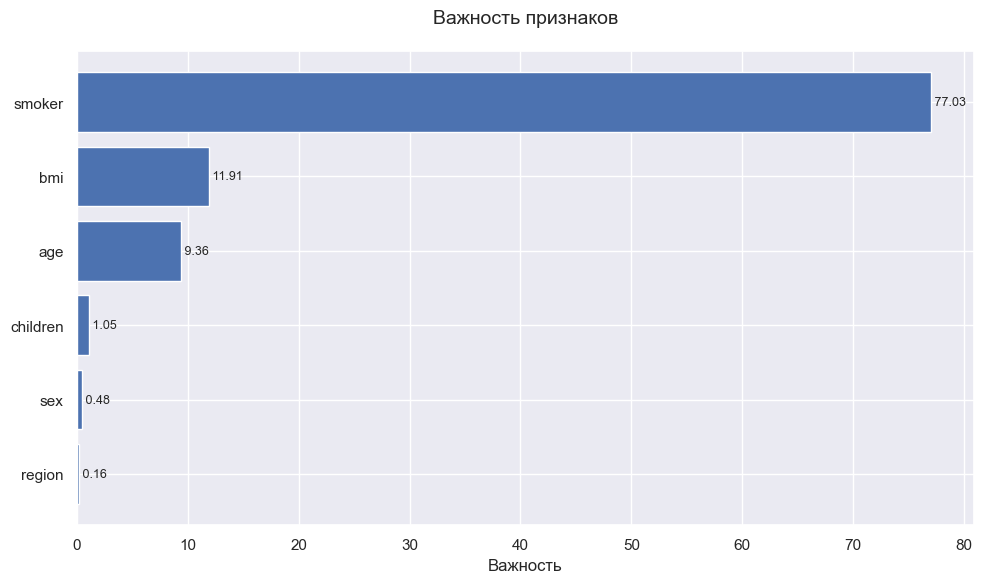

In [32]:
# Вывод графика важности признаков
feature_names = X.columns
importances = cat.feature_importances_

# Сортировка признаков по важности
indices = np.argsort(importances)[::-1]

# Создание графика
plt.figure(figsize=(10, 6))
plt.title(f'Важность признаков', fontsize=14, pad=20)
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Важность', fontsize=12)
plt.gca().invert_yaxis()

# Добавление значений важности на график
for i, (idx, imp) in enumerate(zip(indices, importances[indices])):
    plt.text(imp, i, f' {imp:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Сравнение lr и cat

In [33]:
compare_df = pd.DataFrame({
    'name': ['lr', 'cat'],
    'mae': [lr_mae, cat_mae],
    'mse': [lr_mse, cat_mse],
    'rmse': [lr_rmse, cat_rmse],
    'r2': [lr_r2, cat_r2]
})

In [34]:
compare_df

,name,mae,mse,rmse,r2
0,lr,4186.51,3.36e+07,5799.59,0.78
1,cat,2461.82,1.92e+07,4386.75,0.88


In [35]:
models = {
    'lr': lr,
    'cat': cat
}

compare_df = {
    'name': [],
    'mae': [],
    'mse': [],
    'rmse': [],
    'r2': []
}

result_df = {
    'y_test': y_test,
}

for name in models:
    model = models[name]

    X_train = pd.read_csv('Train/X.csv')
    y_train = pd.read_csv('Train/y.csv').squeeze()
    
    X_test = pd.read_csv('Test/X.csv')
    y_test = pd.read_csv('Test/y.csv').squeeze()

    if name == 'lr':
        for col in X_train.select_dtypes(include=['object']).columns:
            X_train[col] = le.fit_transform(X_train[col])
            X_test[col] = le.transform(X_test[col])
    
    y_train_pred = model.predict(X_train)
    
    compare_df['name'].append(f'{name}-train')
    compare_df['mae'].append(mean_absolute_error(y_train, y_train_pred))
    compare_df['mse'].append(mean_squared_error(y_train, y_train_pred))
    compare_df['rmse'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    compare_df['r2'].append(r2_score(y_train, y_train_pred))
    

    y_test_pred = model.predict(X_test)
    result_df[f'y_test_{name}'] = y_test_pred
    
    compare_df['name'].append(f'{name}-test')
    compare_df['mae'].append(mean_absolute_error(y_test, y_test_pred))
    compare_df['mse'].append(mean_squared_error(y_test, y_test_pred))
    compare_df['rmse'].append(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    compare_df['r2'].append(r2_score(y_test, y_test_pred))

compare_df = pd.DataFrame(compare_df)
result_df = pd.DataFrame(result_df)

In [36]:
compare_df

,name,mae,mse,rmse,r2
0,lr-train,4208.76,3.73e+07,6105.79,0.74
1,lr-test,4186.51,3.36e+07,5799.59,0.78
2,cat-train,2413.26,1.86e+07,4312.50,0.87
3,cat-test,2461.82,1.92e+07,4386.75,0.88


In [37]:
compare_df['model'] = compare_df['name'].apply(lambda x: x.split('-')[0])
compare_df['dataset'] = compare_df['name'].apply(lambda x: x.split('-')[1])

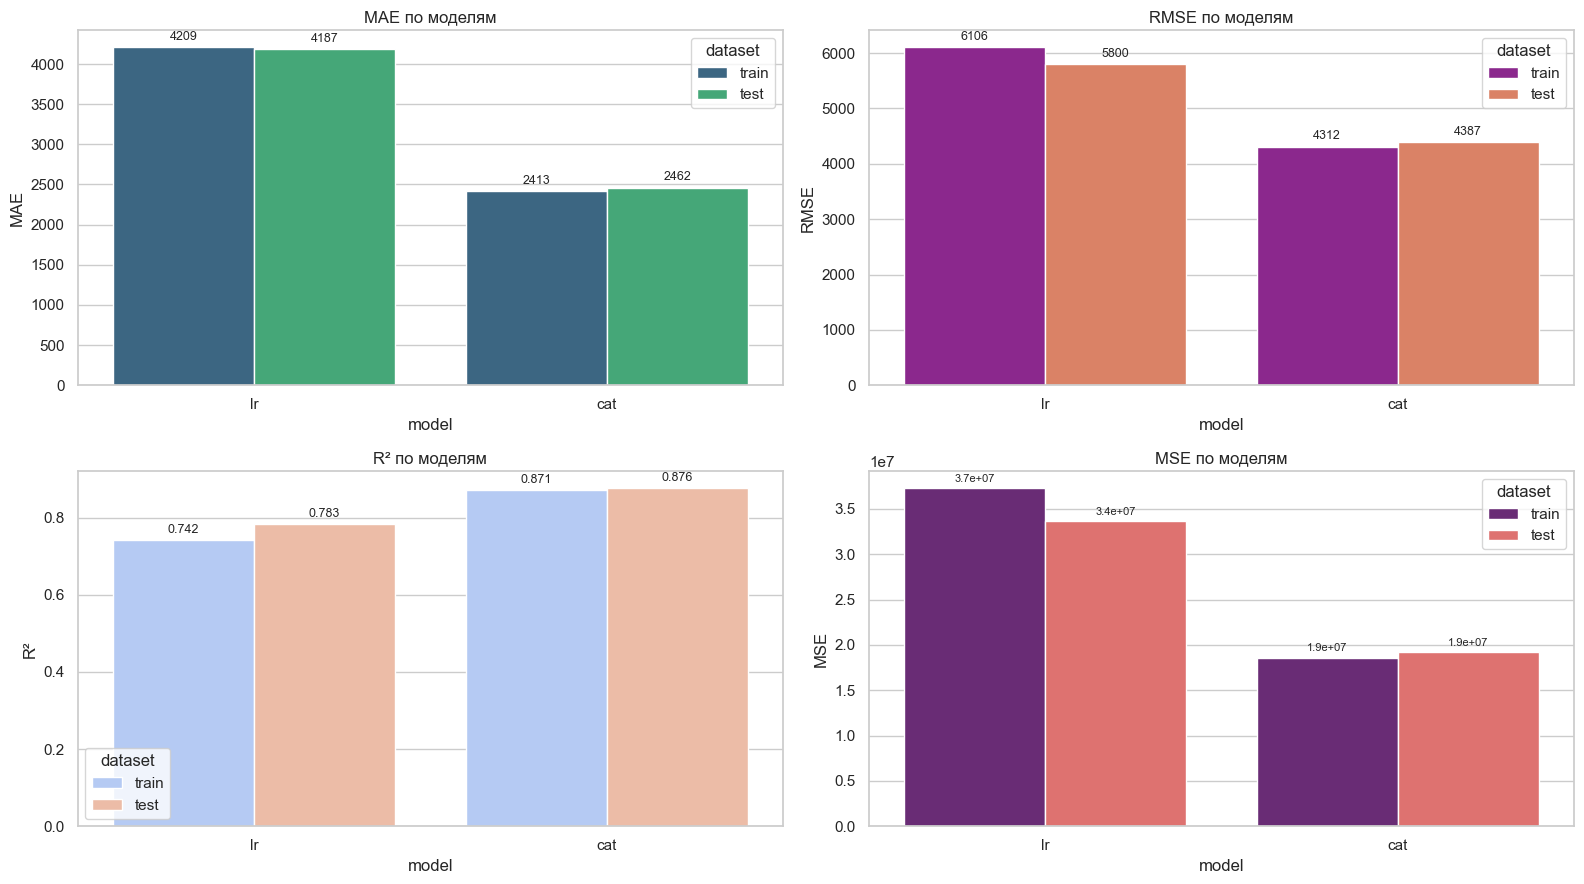

In [38]:
sns.set_style("whitegrid")
plt.figure(figsize=(16, 9))

plt.subplot(2, 2, 1)
ax1 = sns.barplot(data=compare_df, x='model', y='mae', hue='dataset', palette='viridis')
plt.title('MAE по моделям', fontsize=12)
plt.ylabel('MAE')

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f', fontsize=9, padding=3)

plt.subplot(2, 2, 2)
ax2 = sns.barplot(data=compare_df, x='model', y='rmse', hue='dataset', palette='plasma')
plt.title('RMSE по моделям', fontsize=12)
plt.ylabel('RMSE')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.0f', fontsize=9, padding=3)

plt.subplot(2, 2, 3)
ax3 = sns.barplot(data=compare_df, x='model', y='r2', hue='dataset', palette='coolwarm')
plt.title('R² по моделям', fontsize=12)
plt.ylabel('R²')

for container in ax3.containers:
    ax3.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

plt.subplot(2, 2, 4)
ax4 = sns.barplot(data=compare_df, x='model', y='mse', hue='dataset', palette='magma')
plt.title('MSE по моделям', fontsize=12)
plt.ylabel('MSE')

for container in ax4.containers:
    ax4.bar_label(container, fmt='%.1e', fontsize=8, padding=3)

plt.tight_layout()
plt.show()

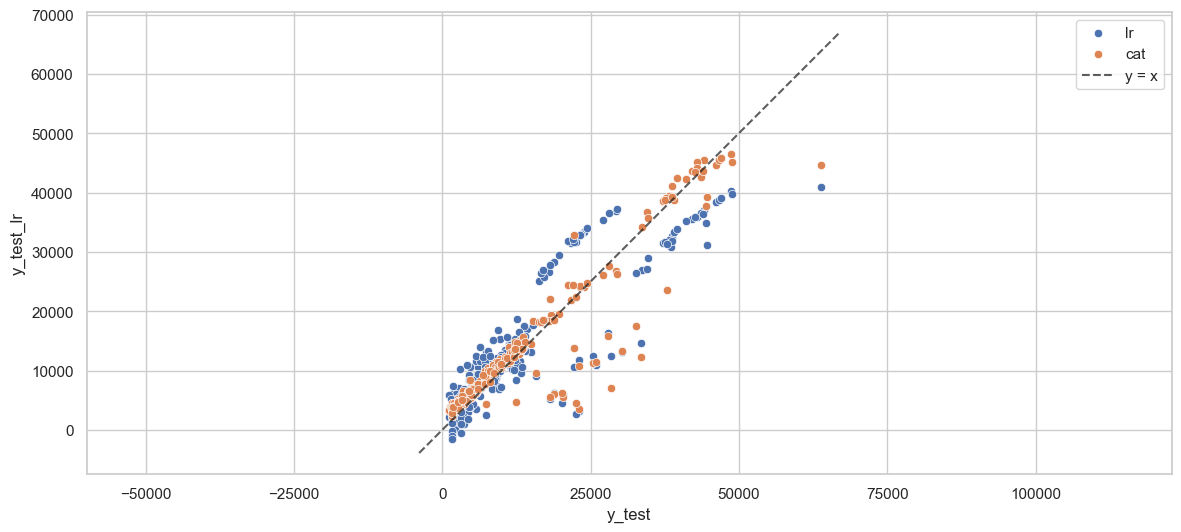

In [39]:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=result_df, x='y_test', y='y_test_lr', label='lr')
sns.scatterplot(data=result_df, x='y_test', y='y_test_cat', label='cat')

x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='y = x', alpha=0.7)

plt.axis('equal')
plt.legend()
plt.show()

In [40]:
compare_test_df = compare_df[compare_df['dataset'].isin(['test'])].reset_index()
best = compare_test_df.loc[compare_test_df['r2'].idxmax()]['model']
metrics = compare_test_df[compare_test_df['model'] == best]

print(f'Лучшая модель - {best}')
print('Метрики на тестовой выборке:')
metrics[['mae', 'mse', 'rmse', 'r2']]

Лучшая модель - cat
Метрики на тестовой выборке:


,mae,mse,rmse,r2
1,2461.82,1.92e+07,4386.75,0.88


### Сохранение лучшей модели

In [41]:
import joblib

joblib.dump(cat, 'cat.joblib')

['cat.joblib']